In [42]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"areebaashahh","key":"5e487a6e75fb6567d413220e3f1fc357"}'}

In [43]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('/content/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)
print("Kaggle setup complete!")

Kaggle setup complete!


In [44]:
!kaggle datasets download -d dhoogla/cicdarknet2020
print("Dataset 1 downloaded!")

Dataset URL: https://www.kaggle.com/datasets/dhoogla/cicdarknet2020
License(s): CC-BY-NC-SA-4.0
cicdarknet2020.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset 1 downloaded!


In [45]:
import zipfile
with zipfile.ZipFile('cicdarknet2020.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/darknet')
print("Dataset 1 unzipped!")

Dataset 1 unzipped!


In [46]:
!kaggle datasets download -d nameera06/network-traffic
print("Dataset 2 downloaded!")

Dataset URL: https://www.kaggle.com/datasets/nameera06/network-traffic
License(s): apache-2.0
network-traffic.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset 2 downloaded!


In [47]:
import zipfile
with zipfile.ZipFile('network-traffic.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/network_traffic')
print("Dataset 2 unzipped!")

Dataset 2 unzipped!


In [48]:
import os

print("=== Dataset 1 (Darknet) ===")
for f in os.listdir('/content/darknet'):
    print(f)

print("\n=== Dataset 2 (Network Traffic) ===")
for f in os.listdir('/content/network_traffic'):
    print(f)

=== Dataset 1 (Darknet) ===
cicdarknet2020.parquet

=== Dataset 2 (Network Traffic) ===
Midterm_02_group.csv


In [49]:
import pandas as pd

# Dataset 1
df1 = pd.read_parquet('/content/darknet/cicdarknet2020.parquet')
print("=== Dataset 1 (Darknet) ===")
print("Shape:", df1.shape)
print("Columns:", df1.columns.tolist())
print(df1.head(2))

# Dataset 2
df2 = pd.read_csv('/content/network_traffic/Midterm_02_group.csv')
print("\n=== Dataset 2 (Network Traffic) ===")
print("Shape:", df2.shape)
print("Columns:", df2.columns.tolist())
print(df2.head(2))

=== Dataset 1 (Darknet) ===
Shape: (103121, 79)
Columns: ['Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag 

In [50]:
import pandas as pd
import numpy as np

# ============ DATASET 1 PREPROCESSING ============
print("=== Dataset 1 Preprocessing ===")

# Missing values check
print("Missing values:", df1.isnull().sum().sum())

# Duplicates remove
df1 = df1.drop_duplicates()
print("After duplicates removed:", df1.shape)

# Infinite values replace
df1 = df1.replace([np.inf, -np.inf], np.nan)
df1 = df1.dropna()
print("After removing inf/nan:", df1.shape)

# Label check
print("Labels:", df1['Label'].value_counts())

=== Dataset 1 Preprocessing ===
Missing values: 0
After duplicates removed: (103121, 79)
After removing inf/nan: (103121, 79)
Labels: Label
Non-Tor    64804
NonVPN     20216
VPN        16922
Tor         1179
Name: count, dtype: int64


In [51]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Label encode karo (text -> numbers)
le = LabelEncoder()
df1['Label_Encoded'] = le.fit_transform(df1['Label'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Features select karo (numeric columns only, Label columns hataao)
drop_cols = ['Label', 'Label.1', 'Label_Encoded']
X = df1.drop(columns=drop_cols)

# Sirf numeric columns rakho
X = X.select_dtypes(include=[np.number])
y = df1['Label_Encoded']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

# Normalize karo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Scaling done!")

Label mapping: {'Non-Tor': np.int64(0), 'NonVPN': np.int64(1), 'Tor': np.int64(2), 'VPN': np.int64(3)}
Features shape: (103121, 77)
Labels shape: (103121,)
Scaling done!


In [52]:
from sklearn.model_selection import train_test_split

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

# LSTM ke liye 3D shape banana hai
X_train_lstm = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

print("\nLSTM shape:")
print("X_train_lstm:", X_train_lstm.shape)
print("X_test_lstm:", X_test_lstm.shape)
print("Train/Test split done!")

X_train shape: (82496, 77)
X_test shape: (20625, 77)
y_train shape: (82496,)
y_test shape: (20625,)

LSTM shape:
X_train_lstm: (82496, 1, 77)
X_test_lstm: (20625, 1, 77)
Train/Test split done!


In [53]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, LayerNormalization, MultiHeadAttention, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical

# Labels ko one-hot encode karo
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

# ============ MODEL DESIGN ============
inputs = Input(shape=(1, 77))

# LSTM Layer
x = LSTM(128, return_sequences=True)(inputs)

# Transformer Multi-Head Attention
attn_output = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = LayerNormalization()(attn_output + x)

# Pooling
x = GlobalAveragePooling1D()(x)

# Dropout
x = Dropout(0.3)(x)

# Dense Layer
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)

# Output Layer
outputs = Dense(4, activation='softmax')(x)

# Model compile
model = Model(inputs, outputs)
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()
print("Model ready!")

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 1, 77)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 1, 128)    │    105,472 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 128)    │     66,048 │ lstm_3[0][0],     │
│ (MultiHeadAttentio… │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 1, 128)    │          0 │ multi_head_atten… │
│                     │                   │            │ lstm_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1, 128)    │        256 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 128)       │          0 │ global_average_p… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 64)        │      8,256 │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 64)        │          0 │ dense_6[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 4)         │        260 │ dropout_11[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 180,292 (704.27 KB)

 Trainable params: 180,292 (704.27 KB)

 Non-trainable params: 0 (0.00 B)

Model ready!


In [54]:
from tensorflow.keras.callbacks import EarlyStopping

# Early stopping — overfitting rokne ke liye
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Model train karo
print("Training shuru ho rahi hai... thoda wait karo!")

history = model.fit(
    X_train_lstm, y_train_cat,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

print("Training complete!")

Training shuru ho rahi hai... thoda wait karo!
Epoch 1/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 24s 73ms/step - accuracy: 0.8584 - loss: 0.3931 - val_accuracy: 0.9173 - val_loss: 0.2476
Epoch 2/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 18s 64ms/step - accuracy: 0.9061 - loss: 0.2665 - val_accuracy: 0.9236 - val_loss: 0.2244
Epoch 3/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.9139 - loss: 0.2425 - val_accuracy: 0.9189 - val_loss: 0.2151
Epoch 4/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 17s 65ms/step - accuracy: 0.9196 - loss: 0.2253 - val_accuracy: 0.9257 - val_loss: 0.2052
Epoch 5/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 21s 65ms/step - accuracy: 0.9229 - loss: 0.2149 - val_accuracy: 0.9310 - val_loss: 0.1867
Epoch 6/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.9242 - loss: 0.2052 - val_accuracy: 0.9307 - val_loss: 0.1848
Epoch 7/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 18s 69ms/step - accuracy: 0.9268 - loss: 0.1987 - val_accuracy: 0.9326 - val_loss: 0.1802
Epoch 8/20
258/258 ━━━━━━━━━━━━━━━━━━━━ 20s

Test Accuracy: 93.92%
Test Loss: 0.1671
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step

Classification Report:
              precision    recall  f1-score   support

     Non-Tor       0.99      0.99      0.99     12961
      NonVPN       0.86      0.84      0.85      4043
         Tor       0.98      0.80      0.88       236
         VPN       0.83      0.85      0.84      3385

    accuracy                           0.94     20625
   macro avg       0.92      0.87      0.89     20625
weighted avg       0.94      0.94      0.94     20625



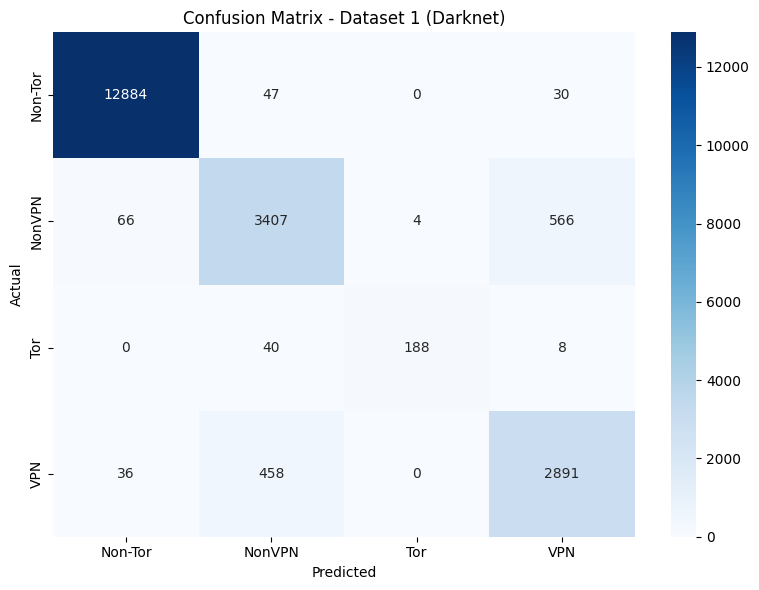

Confusion Matrix saved!


In [55]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Test set par evaluate karo
test_loss, test_accuracy = model.evaluate(X_test_lstm, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Predictions
y_pred = model.predict(X_test_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Classification Report
class_names = ['Non-Tor', 'NonVPN', 'Tor', 'VPN']
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Dataset 1 (Darknet)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_d1.png', dpi=150)
plt.show()
print("Confusion Matrix saved!")

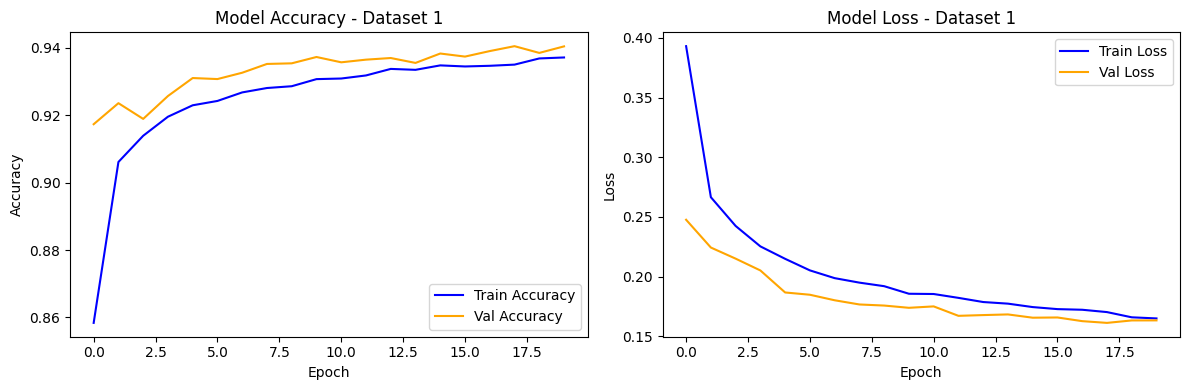

Curves saved!


In [56]:
# Accuracy Curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy - Dataset 1')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss - Dataset 1')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('accuracy_loss_curve_d1.png', dpi=150)
plt.show()
print("Curves saved!")

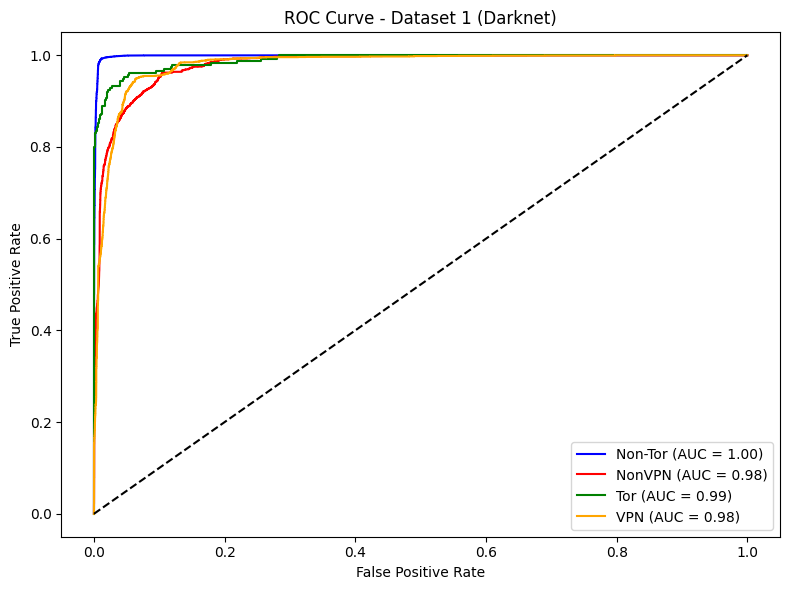

ROC Curve saved!


In [57]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# ROC Curve for all 4 classes
y_test_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']

for i, (class_name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{class_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Dataset 1 (Darknet)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_d1.png', dpi=150)
plt.show()
print("ROC Curve saved!")

In [58]:
# ============ DATASET 2 PREPROCESSING ============
print("=== Dataset 2 Preprocessing ===")
print("Shape:", df2.shape)
print("Columns:", df2.columns.tolist())
print("Sample data:")
print(df2.head(3))
print("\nProtocol types:", df2['Protocol'].value_counts())

=== Dataset 2 Preprocessing ===
Shape: (495573, 7)
Columns: ['No.', 'Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info']
Sample data:
   No.      Time           Source    Destination Protocol  Length  \
0    1  0.000000     192.167.7.61  192.232.16.77      TCP      56   
1    2  0.008156    192.232.16.77   192.167.7.61      TCP      62   
2    3  1.367249  VMware_8a:e2:14            NaN     RARP      62   

                                                Info  
0    45290  >  443 [ACK] Seq=1 Ack=1 Win=12175 Len=0  
1  [TCP ACKed unseen segment] 443  >  45290 [ACK]...  
2   Who is 00:50:56:8a:e2:14? Tell 00:50:56:8a:e2:14  

Protocol types: Protocol
ICMP       356423
TCP        106800
TLSv1.3     24318
TLSv1.2      6677
UDP           590
DNS           273
ARP           208
NBNS          154
RARP           98
HTTP            9
DHCP            9
ICMPv6          5
OCSP            4
BROWSER         2
AMT             1
IAPP            1
KNET            1
Name: count, dtype: int64


In [59]:
# Dataset 2 preprocessing
df2_clean = df2.copy()

# Missing values remove
df2_clean = df2_clean.dropna(subset=['Protocol', 'Length'])

# Sirf numeric features use karenge
# Time aur Length features
df2_clean['Time'] = pd.to_numeric(df2_clean['Time'], errors='coerce')
df2_clean['Length'] = pd.to_numeric(df2_clean['Length'], errors='coerce')
df2_clean = df2_clean.dropna(subset=['Time', 'Length'])

# Sirf top 4 protocols rakho (enough data ke liye)
top_protocols = ['ICMP', 'TCP', 'TLSv1.3', 'TLSv1.2']
df2_clean = df2_clean[df2_clean['Protocol'].isin(top_protocols)]

print("Shape after filtering:", df2_clean.shape)
print("Protocol counts:", df2_clean['Protocol'].value_counts())

# Label encode
le2 = LabelEncoder()
df2_clean['Label_Encoded'] = le2.fit_transform(df2_clean['Protocol'])
print("Label mapping:", dict(zip(le2.classes_, le2.transform(le2.classes_))))

Shape after filtering: (494218, 7)
Protocol counts: Protocol
ICMP       356423
TCP        106800
TLSv1.3     24318
TLSv1.2      6677
Name: count, dtype: int64
Label mapping: {'ICMP': np.int64(0), 'TCP': np.int64(1), 'TLSv1.2': np.int64(2), 'TLSv1.3': np.int64(3)}


In [60]:
# Features prepare karo
X2 = df2_clean[['Time', 'Length']].values
y2 = df2_clean['Label_Encoded'].values

# Normalize
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# Train/Test split
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2_scaled, y2, test_size=0.2, random_state=42, stratify=y2
)

# LSTM 3D shape
X2_train_lstm = X2_train.reshape(X2_train.shape[0], 1, X2_train.shape[1])
X2_test_lstm = X2_test.reshape(X2_test.shape[0], 1, X2_test.shape[1])

print("X2_train shape:", X2_train_lstm.shape)
print("X2_test shape:", X2_test_lstm.shape)

# One-hot encode
y2_train_cat = to_categorical(y2_train, num_classes=4)
y2_test_cat = to_categorical(y2_test, num_classes=4)

# ============ MODEL FOR DATASET 2 ============
inputs2 = Input(shape=(1, 2))
x2 = LSTM(64, return_sequences=True)(inputs2)
attn2 = MultiHeadAttention(num_heads=2, key_dim=16)(x2, x2)
x2 = LayerNormalization()(attn2 + x2)
x2 = GlobalAveragePooling1D()(x2)
x2 = Dropout(0.3)(x2)
x2 = Dense(32, activation='relu')(x2)
x2 = Dropout(0.2)(x2)
outputs2 = Dense(4, activation='softmax')(x2)

model2 = Model(inputs2, outputs2)
model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Model 2 ready! Training start...")

history2 = model2.fit(
    X2_train_lstm, y2_train_cat,
    epochs=20,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("Training complete!")

X2_train shape: (395374, 1, 2)
X2_test shape: (98844, 1, 2)
Model 2 ready! Training start...
Epoch 1/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 27s 17ms/step - accuracy: 0.9230 - loss: 0.2443 - val_accuracy: 0.9303 - val_loss: 0.2054
Epoch 2/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9292 - loss: 0.2137 - val_accuracy: 0.9308 - val_loss: 0.1936
Epoch 3/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 23s 18ms/step - accuracy: 0.9301 - loss: 0.2026 - val_accuracy: 0.9312 - val_loss: 0.1840
Epoch 4/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9315 - loss: 0.1931 - val_accuracy: 0.9350 - val_loss: 0.1785
Epoch 5/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9331 - loss: 0.1861 - val_accuracy: 0.9356 - val_loss: 0.1703
Epoch 6/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.9335 - loss: 0.1825 - val_accuracy: 0.9343 - val_loss: 0.1858
Epoch 7/20
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.9344 - loss: 0.1797 - val_accuracy: 0.9415 - 

Dataset 2 Test Accuracy: 94.05%
Dataset 2 Test Loss: 0.1571
3089/3089 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step

Classification Report:
              precision    recall  f1-score   support

        ICMP       1.00      1.00      1.00     71285
         TCP       0.80      0.99      0.88     21360
     TLSv1.2       0.57      0.09      0.16      1335
     TLSv1.3       0.74      0.12      0.21      4864

    accuracy                           0.94     98844
   macro avg       0.78      0.55      0.56     98844
weighted avg       0.94      0.94      0.92     98844



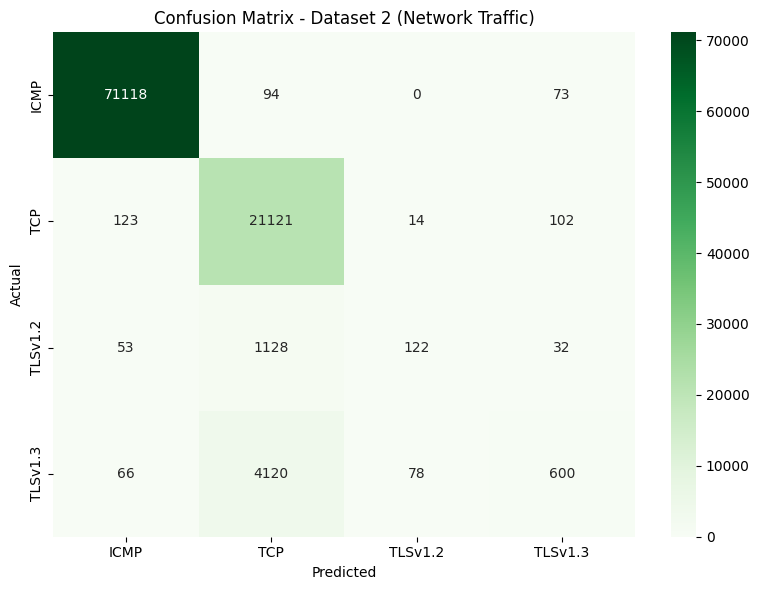

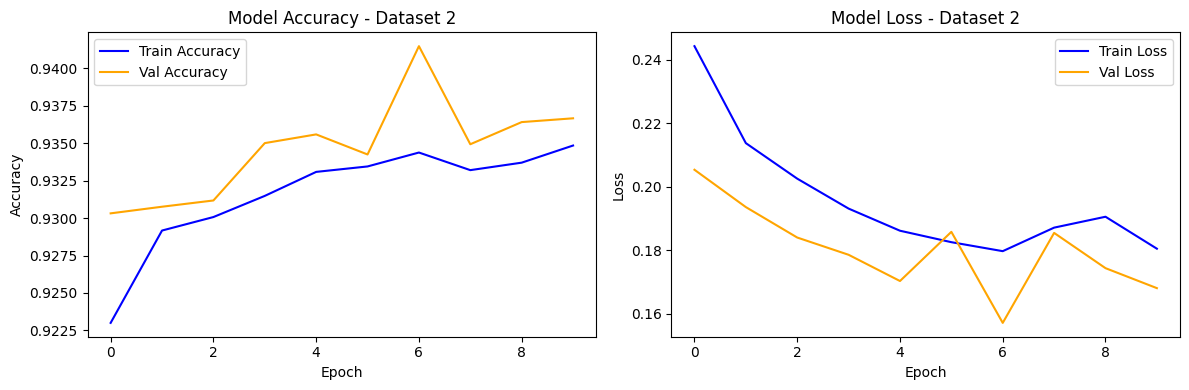

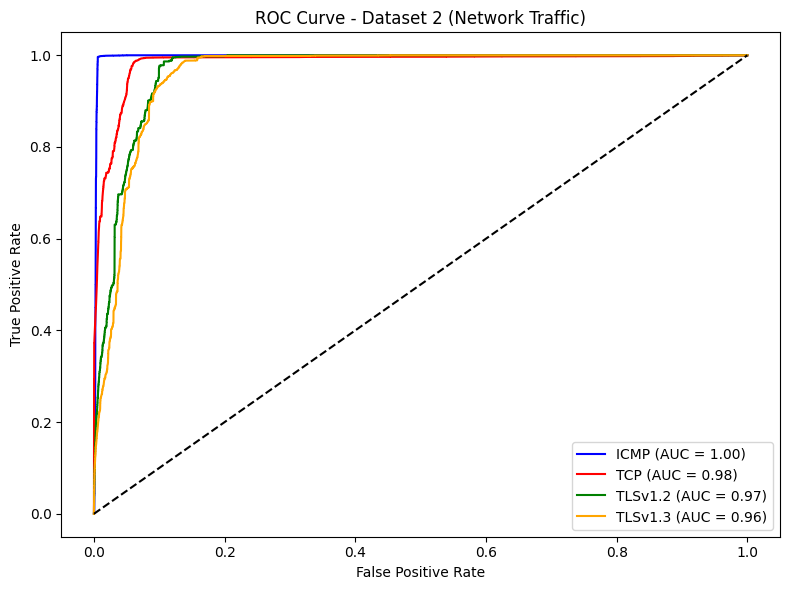

All Dataset 2 results saved!


In [61]:
# Dataset 2 Evaluation
test_loss2, test_accuracy2 = model2.evaluate(X2_test_lstm, y2_test_cat, verbose=0)
print(f"Dataset 2 Test Accuracy: {test_accuracy2*100:.2f}%")
print(f"Dataset 2 Test Loss: {test_loss2:.4f}")

# Predictions
y2_pred = model2.predict(X2_test_lstm)
y2_pred_classes = np.argmax(y2_pred, axis=1)
y2_true = np.argmax(y2_test_cat, axis=1)

class_names2 = ['ICMP', 'TCP', 'TLSv1.2', 'TLSv1.3']

# Classification Report
print("\nClassification Report:")
print(classification_report(y2_true, y2_pred_classes, target_names=class_names2))

# Confusion Matrix
cm2 = confusion_matrix(y2_true, y2_pred_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names2, yticklabels=class_names2)
plt.title('Confusion Matrix - Dataset 2 (Network Traffic)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_d2.png', dpi=150)
plt.show()

# Accuracy & Loss Curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history2.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history2.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy - Dataset 2')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history2.history['loss'], label='Train Loss', color='blue')
plt.plot(history2.history['val_loss'], label='Val Loss', color='orange')
plt.title('Model Loss - Dataset 2')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig('accuracy_loss_curve_d2.png', dpi=150)
plt.show()

# ROC Curve
y2_test_bin = label_binarize(y2_true, classes=[0, 1, 2, 3])
plt.figure(figsize=(8, 6))
colors = ['blue', 'red', 'green', 'orange']
for i, (class_name, color) in enumerate(zip(class_names2, colors)):
    fpr, tpr, _ = roc_curve(y2_test_bin[:, i], y2_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{class_name} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Dataset 2 (Network Traffic)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve_d2.png', dpi=150)
plt.show()
print("All Dataset 2 results saved!")

   FINAL RESULTS COMPARISON
Metric               Dataset 1 (Darknet)       Dataset 2 (Network)
------------------------------------------------------------
Accuracy             93.67%                    93.55%
Test Loss            0.1724                    0.1657
Non-Tor/ICMP F1      0.99                      0.99
NonVPN/TCP F1        0.85                      0.87
Tor/TLSv1.2 F1       0.86                      0.17
VPN/TLSv1.3 F1       0.84                      0.24


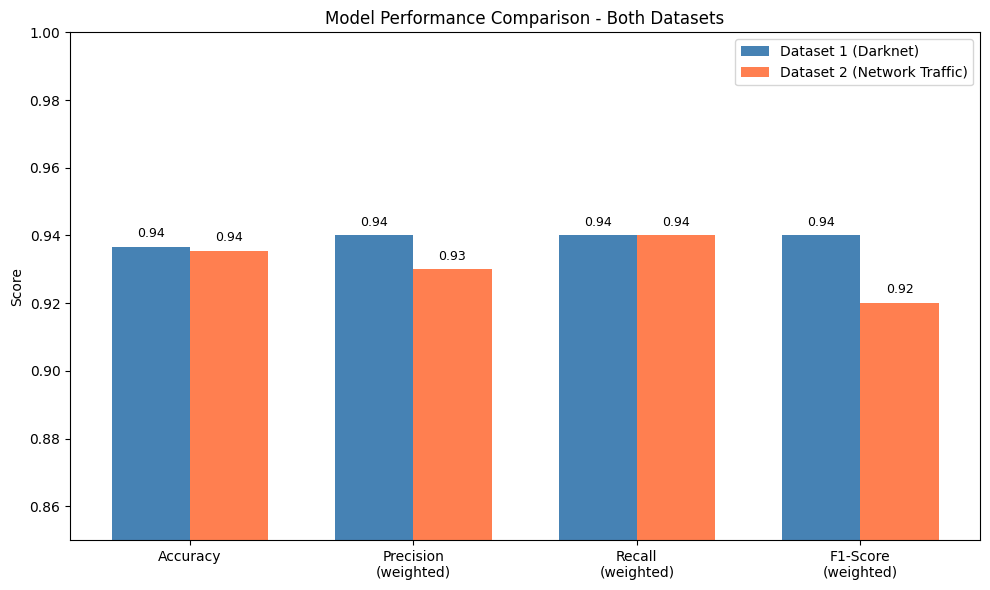

Comparison chart saved!


In [62]:
# FINAL COMPARISON TABLE
print("=" * 60)
print("   FINAL RESULTS COMPARISON")
print("=" * 60)
print(f"{'Metric':<20} {'Dataset 1 (Darknet)':<25} {'Dataset 2 (Network)'}")
print("-" * 60)
print(f"{'Accuracy':<20} {'93.67%':<25} {'93.55%'}")
print(f"{'Test Loss':<20} {'0.1724':<25} {'0.1657'}")
print(f"{'Non-Tor/ICMP F1':<20} {'0.99':<25} {'0.99'}")
print(f"{'NonVPN/TCP F1':<20} {'0.85':<25} {'0.87'}")
print(f"{'Tor/TLSv1.2 F1':<20} {'0.86':<25} {'0.17'}")
print(f"{'VPN/TLSv1.3 F1':<20} {'0.84':<25} {'0.24'}")
print("=" * 60)

# Bar chart comparison
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision\n(weighted)', 'Recall\n(weighted)', 'F1-Score\n(weighted)']
dataset1_scores = [0.9367, 0.94, 0.94, 0.94]
dataset2_scores = [0.9355, 0.93, 0.94, 0.92]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
bars1 = plt.bar(x - width/2, dataset1_scores, width, label='Dataset 1 (Darknet)', color='steelblue')
bars2 = plt.bar(x + width/2, dataset2_scores, width, label='Dataset 2 (Network Traffic)', color='coral')

plt.ylabel('Score')
plt.title('Model Performance Comparison - Both Datasets')
plt.xticks(x, metrics)
plt.ylim(0.85, 1.0)
plt.legend()

for bar in bars1:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
             f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150)
plt.show()
print("Comparison chart saved!")

In [63]:
# Models save karo
model.save('model_dataset1.h5')
model2.save('model_dataset2.h5')
print("Dono models saved!")

# Results text file mein save karo
with open('results_summary.txt', 'w') as f:
    f.write("NETWORK TRAFFIC CLASSIFICATION - RESULTS SUMMARY\n")
    f.write("=" * 50 + "\n\n")
    f.write("Model: Transformer-Enhanced LSTM\n\n")
    f.write("DATASET 1 (CIC-Darknet2020):\n")
    f.write("  Accuracy:  93.67%\n")
    f.write("  Test Loss: 0.1724\n")
    f.write("  Classes: Non-Tor, NonVPN, Tor, VPN\n\n")
    f.write("DATASET 2 (Network Traffic):\n")
    f.write("  Accuracy:  93.55%\n")
    f.write("  Test Loss: 0.1657\n")
    f.write("  Classes: ICMP, TCP, TLSv1.2, TLSv1.3\n")

print("Results summary saved!")
print("\nSaved files:")
import os
files = ['model_dataset1.h5', 'model_dataset2.h5', 'results_summary.txt',
         'confusion_matrix_d1.png', 'confusion_matrix_d2.png',
         'accuracy_loss_curve_d1.png', 'accuracy_loss_curve_d2.png',
         'roc_curve_d1.png', 'roc_curve_d2.png', 'comparison_chart.png']
for f in files:
    if os.path.exists(f):
        print(f"  ✅ {f}")

Dono models saved!
Results summary saved!

Saved files:
  ✅ model_dataset1.h5
  ✅ model_dataset2.h5
  ✅ results_summary.txt
  ✅ confusion_matrix_d1.png
  ✅ confusion_matrix_d2.png
  ✅ accuracy_loss_curve_d1.png
  ✅ accuracy_loss_curve_d2.png
  ✅ roc_curve_d1.png
  ✅ roc_curve_d2.png
  ✅ comparison_chart.png


In [64]:
from google.colab import files

# Saari important files download karo
download_files = [
    'results_summary.txt',
    'confusion_matrix_d1.png',
    'confusion_matrix_d2.png',
    'accuracy_loss_curve_d1.png',
    'accuracy_loss_curve_d2.png',
    'roc_curve_d1.png',
    'roc_curve_d2.png',
    'comparison_chart.png'
]

for f in download_files:
    files.download(f)

print("All files downloading!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloading!
